# Imports

In [1]:
import os

import packages.computing as cp

from packages.mining import open_data
from packages.plotting import plot_data

directory = os.chdir("/home/leopaul/Climate_Change_PO/")

In [2]:
sr = open_data("data/GHI_mean_1940_2025.nc", "ssrdc") / 3.6e6
print(sr)

Series([], Name: ssrdc, dtype: int64)
DatetimeIndex([], dtype='datetime64[ns]', freq=None)
1940-01-01 07:00:00   -0.000076
1940-01-01 08:00:00    0.016739
1940-01-01 09:00:00    0.131412
1940-01-01 10:00:00    0.262013
1940-01-01 11:00:00    0.358026
                         ...   
2025-11-11 18:00:00   -0.000076
2025-11-11 19:00:00   -0.000076
2025-11-11 20:00:00   -0.000076
2025-11-11 21:00:00   -0.000076
2025-11-11 22:00:00   -0.000076
Name: ssrdc, Length: 752680, dtype: float64


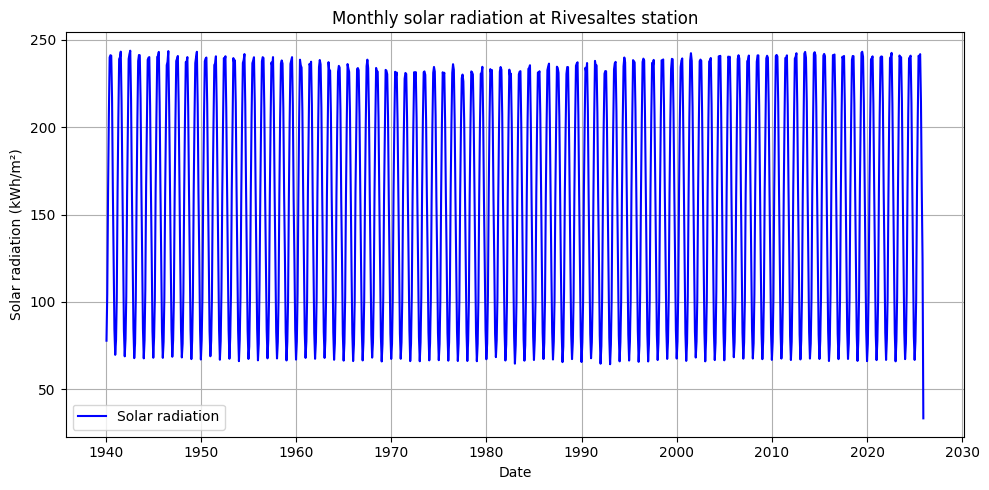

In [3]:
sr_m = sr.resample("ME").sum()
plot_data(
    sr_m,
    "Solar radiation",
    "Monthly solar radiation",
    "solar/monthly_1940_2025",
)

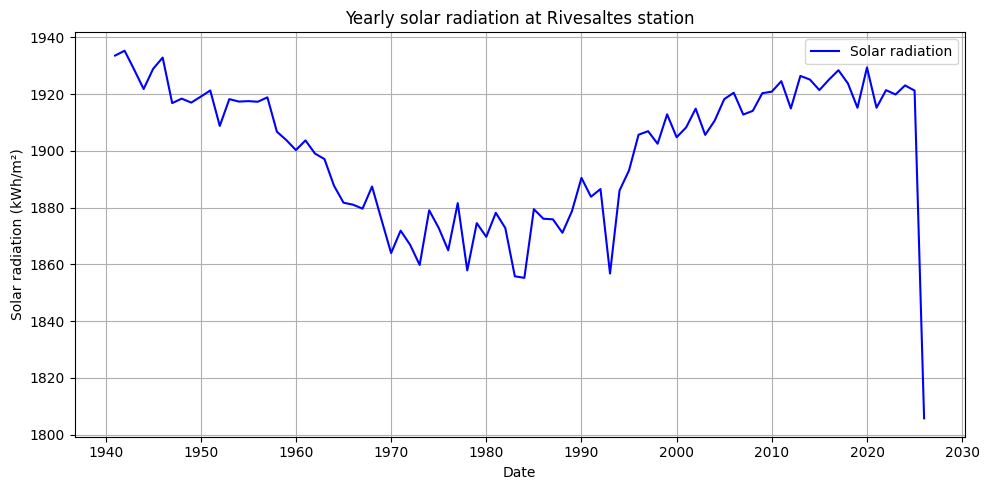

In [4]:
sr_y = sr.resample("YE").sum()
plot_data(
    sr_y,
    "Solar radiation",
    "Yearly solar radiation",
    "solar/yearly_1940_2025",
)

# Normal

In [5]:
sr_d = sr.resample("D").sum()

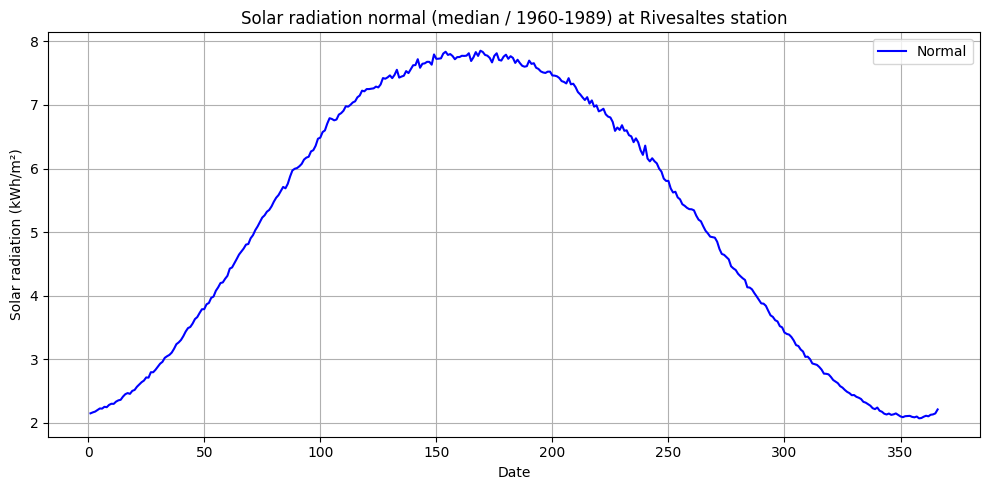

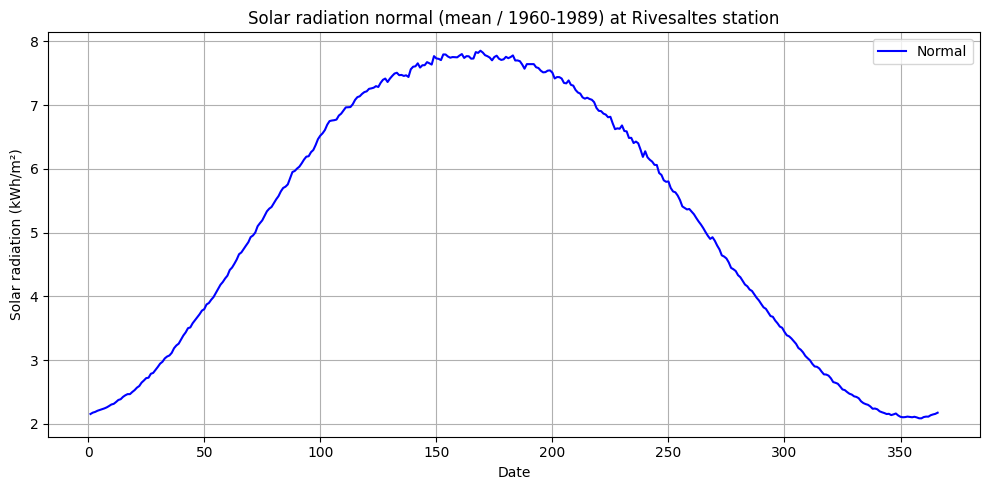

In [10]:
(sr_clim_med, sr_clim_mean) = cp.climatology(
    sr_d,
    "1960-01-01 00:00:00",
    "1989-12-31 23:00:00",
    "Solar radiation",
    "solar"
)

## Moving average

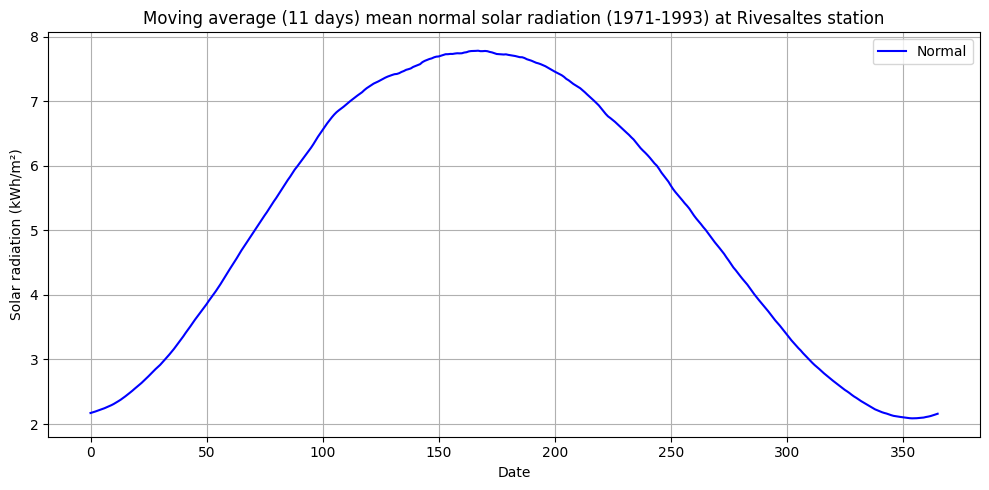

In [14]:
sr_nrm = cp.clim_ma(
    sr_d,
    "solar radiation",
    11,
    "mean",
    "1971-01-01 00:00:00",
    "1993-12-31 23:00:00",
    "solar",
    True
)

# Quantiles

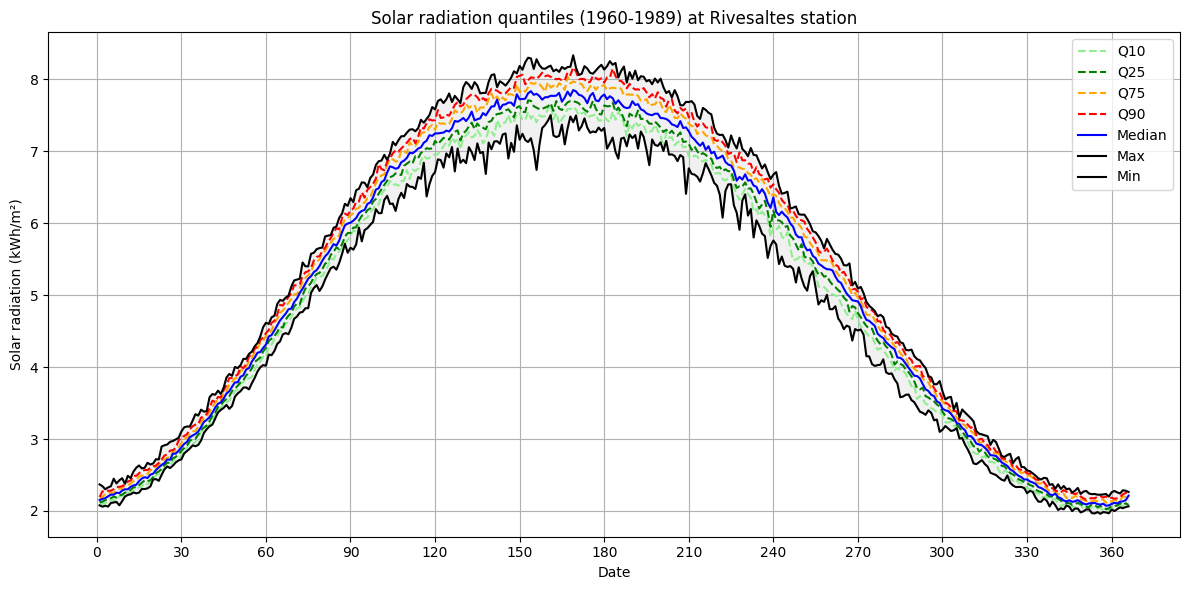

In [8]:
sr_d_loc = sr_d.loc["1960-01-01":"1989-12-31"]
dic_q_frst = cp.quantiles(
    sr_d_loc,
    "avg",
    "Solar radiation quantiles (1960-1989) at Rivesaltes station",
    "Solar radiation (kWh/m²)",
    "solar/quantiles_1960_1989"
)

## Moving average

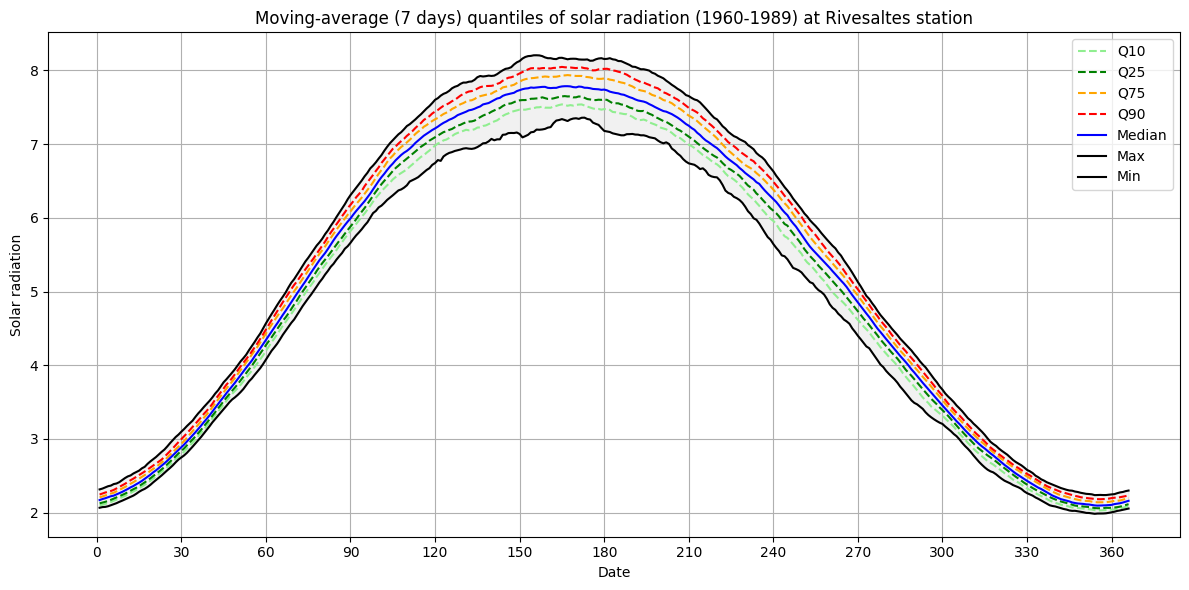

In [9]:
dic_ma_q = cp.ma_quantiles(
    sr_d,
    11,
    "avg",
    "1960-01-01 00:00:00",
    "1989-12-31 23:00:00",
    "Moving-average (7 days) quantiles of solar radiation (1960-1989) at Rivesaltes station",
    "Solar radiation",
    "solar"
)